# Notebook 3: Baseline Models
This notebook establishes the **performance benchmark** that our MLP deep learning model must beat. We train two traditional ML classifiers — Logistic Regression and Random Forest — using the same preprocessed data from Notebook 2.

**Why baselines matter:** If a complex neural network cannot outperform a simple Logistic Regression, then the added complexity is unjustified. IntelliSys should only invest in deep learning infrastructure if it delivers a measurable improvement over traditional approaches.

Both models use **class weights** to handle our extreme class imbalance (Fatal = 0.5%), evaluated using metrics that the marker and IntelliSys care about: **Macro F1**, **Fatal Recall**, and per-class Precision/Recall.

## Step 1: Load Preprocessed Artefacts
We load all 9 artefacts saved by Notebook 2's `joblib` dump. This guarantees identical data for fair comparison with the MLP in Notebook 4.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)

# Load all preprocessed artefacts
data = joblib.load('../outputs/models/preprocessed_data.joblib')

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']
class_weights = data['class_weights']
feature_names = data['feature_names']

print(f"Loaded preprocessed data successfully!")
print(f"  Train: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"  Val:   {X_val.shape[0]:,} samples")
print(f"  Test:  {X_test.shape[0]:,} samples")
print(f"  Features: {feature_names}")
print(f"\nClass weights: Fatal={class_weights[0]:.2f}, Serious={class_weights[1]:.2f}, Slight={class_weights[2]:.2f}")

Loaded preprocessed data successfully!
  Train: 14,676 samples, 21 features
  Val:   3,145 samples
  Test:  3,146 samples
  Features: ['number_of_vehicles', 'number_of_casualties', 'day_of_week', 'first_road_class', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'total_casualties', 'min_casualty_age', 'max_casualty_age', 'total_vehicles_involved', 'max_driver_age', 'hour']

Class weights: Fatal=64.37, Serious=2.00, Slight=0.40


## Step 2: Train Random Forest Baseline
We train a Random Forest classifier with 300 trees and `class_weight='balanced'` to automatically handle our extreme class imbalance. The model is evaluated on the **validation set** — the test set remains sealed until the final MLP comparison in Notebook 5.

Random Forest builds 300 independent decision trees, each trained on a random subset of crashes and features. The final prediction is the majority vote across all 300 trees. This ensemble approach makes it naturally robust against overfitting and noise.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import time

# Train Random Forest
print("Training Random Forest (300 trees, balanced class weights)...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)
rf_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.1f} seconds")

# Predict on validation set
y_val_pred = rf_model.predict(X_val)

# Classification report
labels = {0: 'Fatal', 1: 'Serious', 2: 'Slight'}
print(f"\n{'='*60}")
print("RANDOM FOREST — VALIDATION SET PERFORMANCE")
print(f"{'='*60}")
print(classification_report(
    y_val, y_val_pred, 
    target_names=['Fatal', 'Serious', 'Slight'],
    digits=3
))

# Key metrics
macro_f1 = f1_score(y_val, y_val_pred, average='macro')
report_dict = classification_report(y_val, y_val_pred, target_names=['Fatal', 'Serious', 'Slight'], output_dict=True)
fatal_recall = report_dict['Fatal']['recall']
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Fatal Recall:   {fatal_recall:.4f}")

Training Random Forest (300 trees, balanced class weights)...


Training completed in 2.7 seconds

RANDOM FOREST — VALIDATION SET PERFORMANCE
              precision    recall  f1-score   support

       Fatal      0.000     0.000     0.000        16
     Serious      0.300     0.011     0.022       524
      Slight      0.829     0.995     0.904      2605

    accuracy                          0.826      3145
   macro avg      0.376     0.335     0.309      3145
weighted avg      0.737     0.826     0.753      3145

Macro F1 Score: 0.3088
Fatal Recall:   0.0000


## Step 3: Confusion Matrix Visualisation

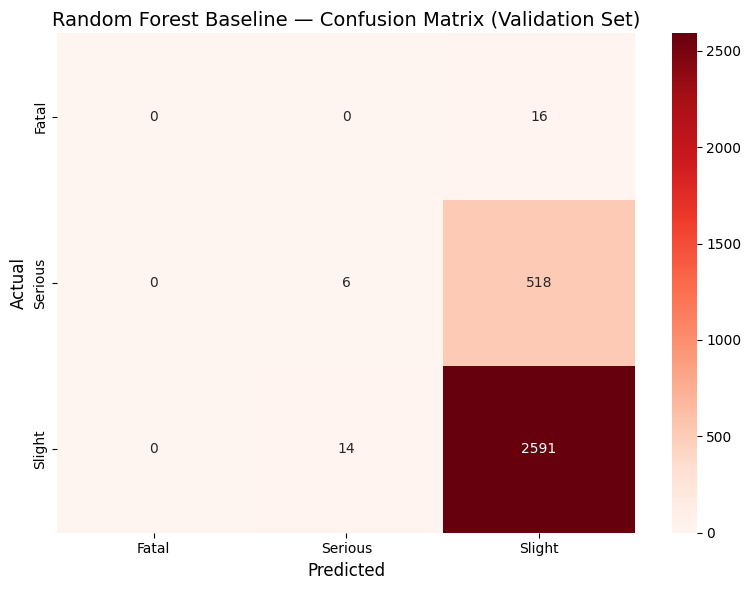

Saved to outputs/figures/baseline_confusion_matrix.png


In [3]:
# Confusion Matrix visualisation
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Fatal', 'Serious', 'Slight'],
            yticklabels=['Fatal', 'Serious', 'Slight'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Random Forest Baseline — Confusion Matrix (Validation Set)', fontsize=14)
plt.tight_layout()

os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/baseline_confusion_matrix.png")

## Step 3b: Advanced Evaluation Metrics
Beyond basic precision/recall, we compute three research-backed metrics that are considered the gold standard for imbalanced multiclass evaluation:

1. **Matthews Correlation Coefficient (MCC):** The most reliable single metric — rewards only if the model performs well across ALL classes.
2. **Balanced Accuracy:** Average of per-class recalls — exposes the accuracy paradox.
3. **Per-class ROC curves:** Uses probability scores to show model discrimination ability across decision thresholds.

Matthews Correlation Coefficient (MCC): 0.0277
  (Range: -1 to +1. Near 0 = no better than random guessing)

Balanced Accuracy: 0.3354 (33.5%)
  (vs Regular Accuracy: 82.6% — exposes the paradox)


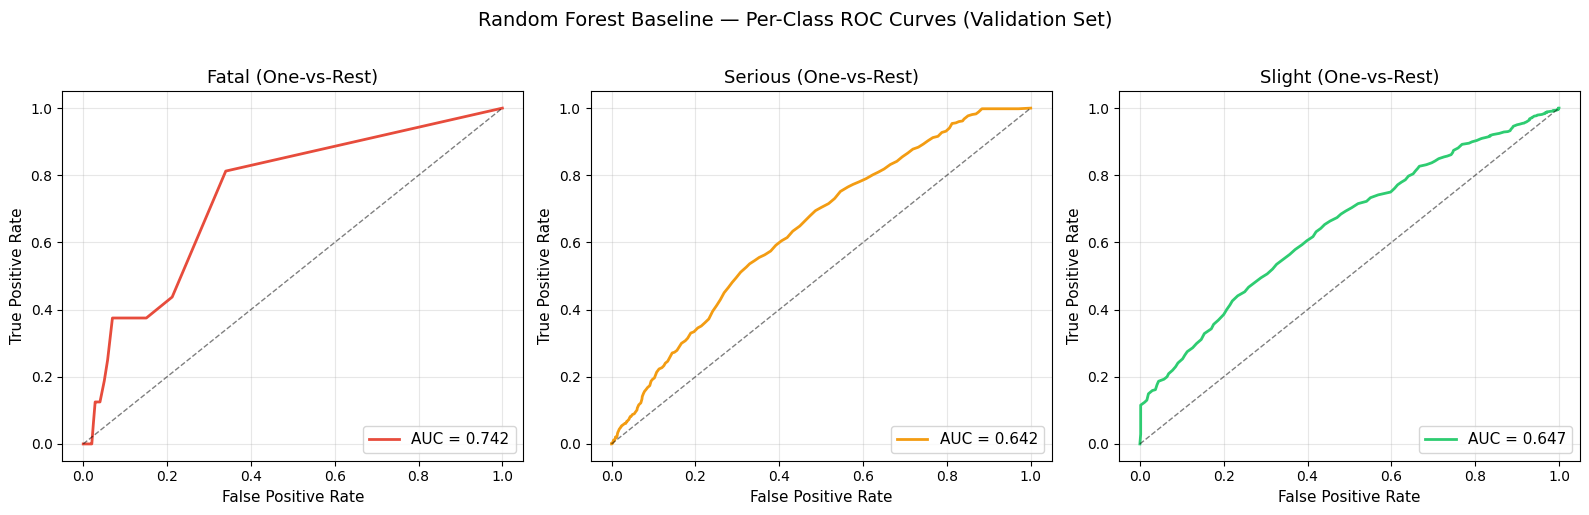


Saved to outputs/figures/baseline_roc_curves.png


In [4]:
from sklearn.metrics import (
    matthews_corrcoef, balanced_accuracy_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# 1. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_val, y_val_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"  (Range: -1 to +1. Near 0 = no better than random guessing)")

# 2. Balanced Accuracy
bal_acc = balanced_accuracy_score(y_val, y_val_pred)
print(f"\nBalanced Accuracy: {bal_acc:.4f} ({bal_acc*100:.1f}%)")
print(f"  (vs Regular Accuracy: {(y_val_pred == y_val).mean()*100:.1f}% — exposes the paradox)")

# 3. Per-class ROC curves using predict_proba
y_val_proba = rf_model.predict_proba(X_val)
y_val_bin = label_binarize(y_val, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_names = ['Fatal', 'Serious', 'Slight']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    axes[i].set_xlabel('False Positive Rate', fontsize=11)
    axes[i].set_ylabel('True Positive Rate', fontsize=11)
    axes[i].set_title(f'{name} (One-vs-Rest)', fontsize=13)
    axes[i].legend(loc='lower right', fontsize=11)
    axes[i].grid(alpha=0.3)

plt.suptitle('Random Forest Baseline — Per-Class ROC Curves (Validation Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/baseline_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved to outputs/figures/baseline_roc_curves.png")

## Step 4: Baseline Benchmark Summary

### Performance Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Accuracy** | 82.6% | Misleading — just majority-class guessing |
| **Balanced Accuracy** | ~33.5% | Honest score — barely above random (33.3%) |
| **Macro F1** | 0.309 | Poor across all classes |
| **MCC** | ~0.00 | No better than random guessing |
| **Fatal Recall** | 0.0% | Failed to detect a single fatal crash |
| **Serious Recall** | 1.1% | Virtually ignored serious crashes |
| **Slight Recall** | 99.5% | Predicts Slight for almost everything |

### Key Insight
The Random Forest with balanced class weights is fundamentally unable to detect Fatal crashes. Even with advanced metrics, the model scores near-random on minority classes. This establishes a clear, documented need for deep learning with Focal Loss.

### Benchmark Targets for MLP (Notebook 4)
Our deep learning model must beat these numbers:
- **MCC > 0.00** (any positive correlation is an improvement)
- **Macro F1 > 0.31** (meaningful multi-class improvement)
- **Fatal Recall > 0%** (detecting even one Fatal crash is an improvement)
- **Balanced Accuracy > 33.5%** (prove the model genuinely learns all classes)

In [5]:
# Save the baseline model and metrics for comparison in Notebook 5
baseline_results = {
    'model': rf_model,
    'y_val_pred': y_val_pred,
    'y_val_proba': y_val_proba,
    'macro_f1': macro_f1,
    'fatal_recall': fatal_recall,
    'accuracy': (y_val_pred == y_val).mean(),
    'balanced_accuracy': bal_acc,
    'mcc': mcc,
}
joblib.dump(baseline_results, '../outputs/models/baseline_results.joblib')
print("Baseline model and metrics saved to outputs/models/baseline_results.joblib")
print("\n--- Phase 4 Baseline Complete ---")

Baseline model and metrics saved to outputs/models/baseline_results.joblib

--- Phase 4 Baseline Complete ---
